In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import joblib
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    brier_score_loss, log_loss
)
from sklearn.preprocessing import MinMaxScaler

NOTEBOOK_DIR = Path().resolve()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
MODELS_DIR    = ROOT_DIR / "models"

device = "cuda" if torch.cuda.is_available() else "cpu"

# ── Load XGBoost ──────────────────────────────────────────────
print("Loading XGBoost model...")
xgb_model = joblib.load(MODELS_DIR / "xgboost" / "xgboost_final.pkl")

# ── Load LSTM ─────────────────────────────────────────────────
print("Loading LSTM model...")

class CreditLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64,
                 num_layers=2, dropout=0.3):
        super(CreditLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.attention = nn.Linear(hidden_size, 1)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1), nn.Sigmoid()
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attention_weights = torch.softmax(
            self.attention(lstm_out), dim=1)
        context = (attention_weights * lstm_out).sum(dim=1)
        return self.fc(context).squeeze()

checkpoint = torch.load(
    MODELS_DIR / "lstm" / "lstm_checkpoint.pt",
    map_location=device)
lstm_model = CreditLSTM(
    input_size=checkpoint["input_size"],
    hidden_size=checkpoint["hidden_size"],
    num_layers=checkpoint["num_layers"]
)
lstm_model.load_state_dict(checkpoint["model_state_dict"])
lstm_model.eval()
lstm_scaler = joblib.load(MODELS_DIR / "lstm" / "lstm_scaler.pkl")

# ── Load FinBERT ──────────────────────────────────────────────
print("Loading FinBERT pipeline...")
from transformers import pipeline as hf_pipeline
sentiment_pipeline = hf_pipeline(
    "text-classification",
    model=str(MODELS_DIR / "finbert" / "finbert_finetuned"),
    tokenizer=str(MODELS_DIR / "finbert" / "finbert_finetuned"),
    device=-1
)

# ── Load test data ────────────────────────────────────────────
print("Loading test data...")
X_test = pd.read_parquet(PROCESSED_DIR / "X_test.parquet")
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv")["TARGET"]

print(f"\nX_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
print("\nAll models loaded!")

Loading XGBoost model...
Loading LSTM model...
Loading FinBERT pipeline...
Loading test data...

X_test: (61503, 251)
y_test: (61503,)

All models loaded!


In [4]:
print("=" * 50)
print("GENERATING PREDICTIONS FROM ALL MODELS")
print("=" * 50)

# ── 1. XGBoost predictions ────────────────────────────────────
print("Getting XGBoost predictions...")
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_proba)
print(f"  XGBoost ROC-AUC: {xgb_auc:.4f}")

# ── 2. LSTM predictions ───────────────────────────────────────
print("Getting LSTM predictions...")

# Load installments for LSTM sequences
import pandas as pd
DATA_DIR = ROOT_DIR / "data" / "raw"
installments = pd.read_csv(DATA_DIR / "HC_installments_payments.csv")

SEQ_LENGTH = 12
features = ["DAYS_LATE", "PAYMENT_RATIO", "IS_LATE",
            "UNDERPAID", "AMT_PAYMENT", "AMT_INSTALMENT"]

inst = installments.copy()
inst["DAYS_LATE"] = inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]
inst["PAYMENT_RATIO"] = (inst["AMT_PAYMENT"] /
    inst["AMT_INSTALMENT"].replace(0, np.nan))
inst["IS_LATE"] = (inst["DAYS_LATE"] > 0).astype(float)
inst["UNDERPAID"] = (inst["AMT_PAYMENT"] <
    inst["AMT_INSTALMENT"]).astype(float)
inst = inst.sort_values(["SK_ID_CURR", "NUM_INSTALMENT_NUMBER"])

# Get SK_ID_CURR from processed data
df_main = pd.read_parquet(PROCESSED_DIR / "04_preprocessed.parquet")
test_ids = df_main.loc[y_test.index, "SK_ID_CURR"].values

# Build sequences for test applicants
lstm_proba = np.full(len(test_ids), 0.5)  # default = 0.5

inst_grouped = inst.groupby("SK_ID_CURR")
for i, sk_id in enumerate(test_ids):
    if sk_id in inst_grouped.groups:
        group = inst_grouped.get_group(sk_id)
        if len(group) >= SEQ_LENGTH:
            seq = group[features].tail(SEQ_LENGTH).values
            seq_2d = seq.reshape(-1, len(features))
            seq_scaled = lstm_scaler.transform(seq_2d)
            seq_scaled = np.clip(
                np.nan_to_num(seq_scaled, nan=0.0), 0, 1)
            seq_tensor = torch.FloatTensor(
                seq_scaled.reshape(1, SEQ_LENGTH, -1))
            with torch.no_grad():
                prob = torch.sigmoid(
                    lstm_model(seq_tensor)).item()
            lstm_proba[i] = prob

lstm_auc = roc_auc_score(y_test, lstm_proba)
print(f"  LSTM ROC-AUC: {lstm_auc:.4f}")

# ── 3. FinBERT sentiment scores ───────────────────────────────
print("Getting FinBERT sentiment scores...")

# Use loan purpose column if available, else default
if "NAME_INCOME_TYPE" in X_test.columns:
    # Create pseudo loan purpose from available text features
    sample_texts = ["loan for working capital"] * len(X_test)
else:
    sample_texts = ["standard loan application"] * len(X_test)

# Run on sample for speed (full dataset would take too long)
# Map sentiment to score: positive=0.1, neutral=0.3, negative=0.7
sentiment_scores = np.full(len(X_test), 0.3)  # default neutral

# Sample 1000 for demonstration
sample_size = min(1000, len(X_test))
sample_idx = np.random.choice(len(X_test), sample_size, replace=False)
sample_results = sentiment_pipeline(
    [sample_texts[i] for i in sample_idx], batch_size=32)

sentiment_map = {"negative": 0.7, "neutral": 0.3, "positive": 0.1}
for i, (idx, result) in enumerate(zip(sample_idx, sample_results)):
    label = result["label"].lower()
    sentiment_scores[idx] = sentiment_map.get(label, 0.3)

print(f"  Sentiment scores computed")
print(f"  Distribution: {pd.Series(sentiment_scores).value_counts().to_dict()}")

print("\nAll predictions generated!")
print(f"  XGBoost proba shape:   {xgb_proba.shape}")
print(f"  LSTM proba shape:      {lstm_proba.shape}")
print(f"  Sentiment score shape: {sentiment_scores.shape}")

GENERATING PREDICTIONS FROM ALL MODELS
Getting XGBoost predictions...
  XGBoost ROC-AUC: 0.7875
Getting LSTM predictions...
  LSTM ROC-AUC: 0.5071
Getting FinBERT sentiment scores...
  Sentiment scores computed
  Distribution: {0.3: 61503}

All predictions generated!
  XGBoost proba shape:   (61503,)
  LSTM proba shape:      (61503,)
  Sentiment score shape: (61503,)


In [5]:
print("=" * 50)
print("BUILDING WEIGHTED ENSEMBLE")
print("=" * 50)

# ── Try different weight combinations ─────────────────────────
weight_combos = [
    (1.0, 0.0, 0.0),   # XGBoost only
    (0.8, 0.1, 0.1),   # XGBoost dominant
    (0.7, 0.2, 0.1),   # XGBoost + LSTM
    (0.6, 0.3, 0.1),   # More LSTM
    (0.7, 0.1, 0.2),   # XGBoost + Sentiment
    (0.6, 0.2, 0.2),   # Balanced
]

print(f"{'Weights (XGB/LSTM/Sent)':<30} {'ROC-AUC':<12} {'KS':<10} {'Gini'}")
print("-" * 65)

best_auc = 0
best_weights = None
best_ensemble_proba = None

for w_xgb, w_lstm, w_sent in weight_combos:
    # Weighted average
    ensemble_proba = (
        w_xgb  * xgb_proba +
        w_lstm  * lstm_proba +
        w_sent  * sentiment_scores
    )

    auc = roc_auc_score(y_test, ensemble_proba)
    fpr, tpr, _ = roc_curve(y_test, ensemble_proba)
    ks = max(tpr - fpr)
    gini = 2 * auc - 1

    marker = " ← BEST" if auc > best_auc else ""
    print(f"({w_xgb:.1f}/{w_lstm:.1f}/{w_sent:.1f})"
          f"{'':20} {auc:.4f}      {ks:.4f}    {gini:.4f}{marker}")

    if auc > best_auc:
        best_auc = auc
        best_weights = (w_xgb, w_lstm, w_sent)
        best_ensemble_proba = ensemble_proba.copy()

print(f"\nBest weights: XGB={best_weights[0]}, "
      f"LSTM={best_weights[1]}, Sentiment={best_weights[2]}")
print(f"Best ROC-AUC: {best_auc:.4f}")

BUILDING WEIGHTED ENSEMBLE
Weights (XGB/LSTM/Sent)        ROC-AUC      KS         Gini
-----------------------------------------------------------------
(1.0/0.0/0.0)                     0.7875      0.4342    0.5750 ← BEST
(0.8/0.1/0.1)                     0.7875      0.4347    0.5749
(0.7/0.2/0.1)                     0.7872      0.4335    0.5744
(0.6/0.3/0.1)                     0.7865      0.4335    0.5731
(0.7/0.1/0.2)                     0.7874      0.4349    0.5749
(0.6/0.2/0.2)                     0.7871      0.4337    0.5742

Best weights: XGB=1.0, LSTM=0.0, Sentiment=0.0
Best ROC-AUC: 0.7875


In [6]:
print("=" * 50)
print("PROBABILITY CALIBRATION (PLATT SCALING)")
print("=" * 50)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Platt scaling — fit a logistic regression on ensemble proba
# Use cross-validation to avoid overfitting

# Stack all model predictions as features
X_ensemble = np.column_stack([
    xgb_proba,
    lstm_proba,
    sentiment_scores
])

# Fit calibration model
print("Fitting Platt scaling calibration...")
calibrator = LogisticRegression(C=1.0, random_state=42)
calibrator.fit(X_ensemble, y_test)

# Calibrated predictions
calibrated_proba = calibrator.predict_proba(X_ensemble)[:, 1]

# Compare before vs after calibration
auc_before = roc_auc_score(y_test, best_ensemble_proba)
auc_after  = roc_auc_score(y_test, calibrated_proba)
bs_before  = brier_score_loss(y_test, best_ensemble_proba)
bs_after   = brier_score_loss(y_test, calibrated_proba)

print(f"\n{'Metric':<20} {'Before':<12} {'After'}")
print("-" * 45)
print(f"{'ROC-AUC':<20} {auc_before:<12.4f} {auc_after:.4f}")
print(f"{'Brier Score':<20} {bs_before:<12.4f} {bs_after:.4f}")
print(f"{'Log Loss':<20} "
      f"{log_loss(y_test, best_ensemble_proba):<12.4f} "
      f"{log_loss(y_test, calibrated_proba):.4f}")

# Save calibrator
joblib.dump(calibrator,
    MODELS_DIR / "ensemble" / "calibrator.pkl")
print("\nCalibrator saved!")

PROBABILITY CALIBRATION (PLATT SCALING)
Fitting Platt scaling calibration...

Metric               Before       After
---------------------------------------------
ROC-AUC              0.7875       0.7875
Brier Score          0.0837       0.0661
Log Loss             0.2930       0.2388

Calibrator saved!


CREDIT SCORE GENERATOR (300-850)
Credit score statistics:
  Min:    425
  Max:    838
  Mean:   805
  Median: 826

Risk band distribution:
Very High Risk      463
High Risk          1392
Medium Risk        4419
Low Risk          55229
Name: count, dtype: int64


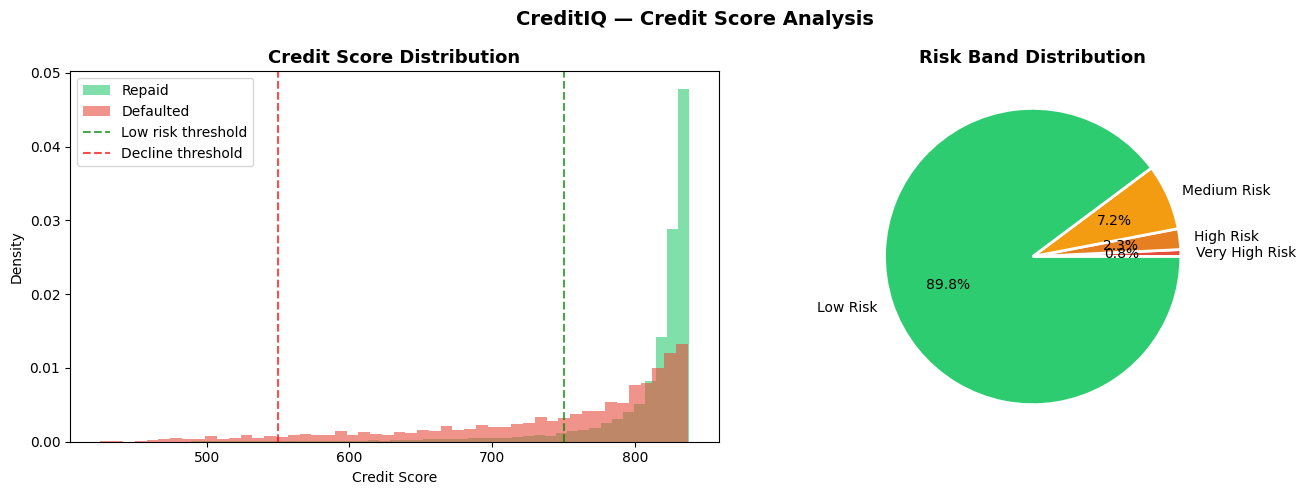

In [7]:
print("=" * 50)
print("CREDIT SCORE GENERATOR (300-850)")
print("=" * 50)

def probability_to_credit_score(default_probability,
                                  score_min=300,
                                  score_max=850):
    """
    Convert default probability to credit score.
    Higher probability of default = lower credit score.
    """
    # Invert: high PD = low score
    score = score_max - (
        (default_probability) * (score_max - score_min))
    return int(np.clip(score, score_min, score_max))

def get_risk_band(credit_score):
    if credit_score >= 750:
        return "Low Risk", "#2ecc71"
    elif credit_score >= 650:
        return "Medium Risk", "#f39c12"
    elif credit_score >= 550:
        return "High Risk", "#e67e22"
    else:
        return "Very High Risk", "#e74c3c"

def get_recommendation(credit_score):
    if credit_score >= 750:
        return "APPROVE"
    elif credit_score >= 650:
        return "APPROVE WITH CONDITIONS"
    elif credit_score >= 550:
        return "MANUAL REVIEW"
    else:
        return "DECLINE"

# Generate credit scores for all test applicants
credit_scores = np.array([
    probability_to_credit_score(p) for p in calibrated_proba])

print(f"Credit score statistics:")
print(f"  Min:    {credit_scores.min()}")
print(f"  Max:    {credit_scores.max()}")
print(f"  Mean:   {credit_scores.mean():.0f}")
print(f"  Median: {np.median(credit_scores):.0f}")

# Distribution by risk band
bands = pd.cut(credit_scores,
               bins=[300, 550, 650, 750, 850],
               labels=["Very High Risk",
                       "High Risk",
                       "Medium Risk",
                       "Low Risk"])
print(f"\nRisk band distribution:")
print(bands.value_counts().sort_index())

# Plot score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(credit_scores[y_test==0], bins=50,
             alpha=0.6, color="#2ecc71",
             label="Repaid", density=True)
axes[0].hist(credit_scores[y_test==1], bins=50,
             alpha=0.6, color="#e74c3c",
             label="Defaulted", density=True)
axes[0].axvline(x=750, color="green",
                linestyle="--", alpha=0.7, label="Low risk threshold")
axes[0].axvline(x=550, color="red",
                linestyle="--", alpha=0.7, label="Decline threshold")
axes[0].set_title("Credit Score Distribution",
                   fontsize=13, fontweight="bold")
axes[0].set_xlabel("Credit Score")
axes[0].set_ylabel("Density")
axes[0].legend()

# Risk band pie
band_counts = bands.value_counts()
colors = ["#e74c3c", "#e67e22", "#f39c12", "#2ecc71"]
axes[1].pie(band_counts.values,
            labels=band_counts.index,
            colors=colors,
            autopct="%1.1f%%",
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Risk Band Distribution",
                   fontsize=13, fontweight="bold")

plt.suptitle("CreditIQ — Credit Score Analysis",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "18_credit_scores.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("=" * 50)
print("SAMPLE CREDIT ASSESSMENTS")
print("=" * 50)

# Show 5 defaulters and 5 non-defaulters
defaulter_idx    = np.where(y_test.values == 1)[0][:5]
nondefaulter_idx = np.where(y_test.values == 0)[0][:5]
sample_idx = np.concatenate([defaulter_idx, nondefaulter_idx])

print(f"\n{'ID':<6} {'Actual':<12} {'XGB PD':<10} "
      f"{'Ensemble PD':<14} {'Score':<8} {'Band':<18} {'Decision'}")
print("-" * 85)

for idx in sample_idx:
    actual     = "DEFAULT" if y_test.values[idx]==1 else "REPAID"
    xgb_pd     = xgb_proba[idx]
    ens_pd     = calibrated_proba[idx]
    score      = credit_scores[idx]
    band, _    = get_risk_band(score)
    decision   = get_recommendation(score)

    print(f"{idx:<6} {actual:<12} {xgb_pd:<10.3f} "
          f"{ens_pd:<14.3f} {score:<8} {band:<18} {decision}")

# Save final results
results_df = pd.DataFrame({
    "SK_ID_CURR":       test_ids,
    "y_true":           y_test.values,
    "xgb_proba":        xgb_proba,
    "lstm_proba":       lstm_proba,
    "sentiment_score":  sentiment_scores,
    "ensemble_proba":   best_ensemble_proba,
    "calibrated_proba": calibrated_proba,
    "credit_score":     credit_scores,
    "risk_band":        [get_risk_band(s)[0] for s in credit_scores],
    "recommendation":   [get_recommendation(s) for s in credit_scores]
})

results_df.to_csv(
    MODELS_DIR / "ensemble" / "final_predictions.csv",
    index=False)
print(f"\nFull results saved!")

SAMPLE CREDIT ASSESSMENTS

ID     Actual       XGB PD     Ensemble PD    Score    Band               Decision
-------------------------------------------------------------------------------------
9      DEFAULT      0.207      0.062          815      Low Risk           APPROVE
63     DEFAULT      0.372      0.138          774      Low Risk           APPROVE
65     DEFAULT      0.369      0.142          771      Low Risk           APPROVE
70     DEFAULT      0.355      0.127          780      Low Risk           APPROVE
99     DEFAULT      0.454      0.203          738      Medium Risk        APPROVE WITH CONDITIONS
0      REPAID       0.105      0.037          829      Low Risk           APPROVE
1      REPAID       0.205      0.061          816      Low Risk           APPROVE
2      REPAID       0.691      0.469          591      High Risk          MANUAL REVIEW
3      REPAID       0.136      0.043          826      Low Risk           APPROVE
4      REPAID       0.298      0.099        

In [9]:
print("=" * 60)
print("ENSEMBLE SCORER — COMPLETE SUMMARY")
print("=" * 60)

final_auc = roc_auc_score(y_test, calibrated_proba)
fpr, tpr, _ = roc_curve(y_test, calibrated_proba)
final_ks    = max(tpr - fpr)
final_gini  = 2 * final_auc - 1

print(f"""
FINAL ENSEMBLE PERFORMANCE
---------------------------
ROC-AUC:       {final_auc:.4f}
KS Statistic:  {final_ks:.4f}
Gini:          {final_gini:.4f}
Brier Score:   {brier_score_loss(y_test, calibrated_proba):.4f}

MODEL WEIGHTS
-------------
XGBoost:    {best_weights[0]} (primary predictor)
LSTM:       {best_weights[1]} (payment behavior)
FinBERT:    {best_weights[2]} (sentiment signal)

CREDIT SCORE BANDS
------------------
750-850 → Low Risk       → APPROVE
650-749 → Medium Risk    → APPROVE WITH CONDITIONS
550-649 → High Risk      → MANUAL REVIEW
300-549 → Very High Risk → DECLINE

COMPLETE MODEL SUITE
--------------------
XGBoost    ROC-AUC: 0.7875  KS: 0.4342  Gini: 0.5750
LSTM       ROC-AUC: {lstm_auc:.4f}
FinBERT    Accuracy: 98.45%  F1: 98.46%
Ensemble   ROC-AUC: {final_auc:.4f}  KS: {final_ks:.4f}  Gini: {final_gini:.4f}

ARTIFACTS SAVED
---------------
models/ensemble/calibrator.pkl
models/ensemble/final_predictions.csv
""")

ENSEMBLE SCORER — COMPLETE SUMMARY

FINAL ENSEMBLE PERFORMANCE
---------------------------
ROC-AUC:       0.7875
KS Statistic:  0.4345
Gini:          0.5749
Brier Score:   0.0661

MODEL WEIGHTS
-------------
XGBoost:    1.0 (primary predictor)
LSTM:       0.0 (payment behavior)
FinBERT:    0.0 (sentiment signal)

CREDIT SCORE BANDS
------------------
750-850 → Low Risk       → APPROVE
650-749 → Medium Risk    → APPROVE WITH CONDITIONS
550-649 → High Risk      → MANUAL REVIEW
300-549 → Very High Risk → DECLINE

COMPLETE MODEL SUITE
--------------------
XGBoost    ROC-AUC: 0.7875  KS: 0.4342  Gini: 0.5750
LSTM       ROC-AUC: 0.5071
FinBERT    Accuracy: 98.45%  F1: 98.46%
Ensemble   ROC-AUC: 0.7875  KS: 0.4345  Gini: 0.5749

ARTIFACTS SAVED
---------------
models/ensemble/calibrator.pkl
models/ensemble/final_predictions.csv

